In [1]:
%load_ext autoreload
%autoreload 2

# python
import os
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep
hep.style.use("ATLAS")
# import pandas as pd
import math
import sys
sys.path.append("../")
import socket
import glob
import json
import itertools

# custom
import Utils as ut

In [2]:
top_dir = "/home/badea/e+e-/aleph/unfold-ee-logtau/ibu_results/training-be9fb5f7/"
filePath = os.path.join(top_dir, "*/conf.json")
fileList = sorted(glob.glob(filePath))
print(len(fileList))

16


In [3]:
def loadWeightPaths(fileList):
    
    d = {}

    for file_path in fileList:
        with open(file_path) as f:
            conf = json.load(f)

        job_type = conf["job_type"]
        data_key = conf["data"].split("_thrust_")[-1].split("_t.root")[0]
        niter = conf["niter"]
        weight_path = os.path.dirname(file_path)

        if job_type not in d:
            d[job_type] = {}

        key2 = niter if job_type == "NiterScan" else data_key
        if key2 not in d[job_type]:
            d[job_type][key2] = []

        # load weight
        d[job_type][key2] = np.load(os.path.join(weight_path, "ibu_phis.npy"))[-1] # last one is the final iteration

        # load stat uncertainty
        if job_type == "Nominal":
            d["MCStat"] = {}
            d["MCStat"]["nominal"] = np.load(os.path.join(weight_path, "ibu_phi_unc.npy"))

            d["HadronicSelectionCorrection"] = {}
            d["HadronicSelectionCorrection"]["nominal"] = np.load(os.path.join(weight_path, "hadronic_event_sel_corr.npy"))
        
    return d

w = loadWeightPaths(fileList)
for key, val in w.items():
    for k, v in val.items():
        print(key, k, v.shape)

Systematics ech10 (42,)
Systematics pt04 (42,)
Systematics ntpc7 (42,)
Systematics no_neutrals (42,)
Systematics with_met (42,)
NiterScan 5 (42,)
NiterScan 3 (42,)
NiterScan 1 (42,)
NiterScan 6 (42,)
NiterScan 4 (42,)
NiterScan 2 (42,)
TheoryUncertainty_Sherpa nominal (42,)
Nominal nominal (42,)
MCStat nominal (42,)
HadronicSelectionCorrection nominal (42,)
TheoryUncertainty_Pythia8 nominal (42,)
TheoryUncertainty_Herwig nominal (42,)
ClosureTest nominal (42,)


In [4]:
# experimental systematic 
exp_syst_names = []
exp_syst = []
for key, val in w["Systematics"].items():
    exp_syst_names.append(key)
    exp_syst.append(w["Nominal"]["nominal"] - val)
exp_syst = np.stack(exp_syst)
print(exp_syst.shape)
total_exp_syst = np.sqrt(np.sum(exp_syst**2, axis=0))
print(total_exp_syst.shape)

(5, 42)
(42,)


In [5]:
# theoretical uncertainty
th_syst_names = ["Pythia8", "Herwig", "Sherpa"]
th_syst = []
for key in th_syst_names:
    th_syst.append(w["Nominal"]["nominal"] - w[f"TheoryUncertainty_{key}"]["nominal"])
th_syst = np.stack(th_syst)
print(th_syst.shape)
total_th_syst = np.sqrt(np.sum(th_syst**2, axis=0))
print(total_th_syst.shape)

(3, 42)
(42,)


In [6]:
total_uncert = np.sqrt(
    w["MCStat"]["nominal"]**2 + 
    total_exp_syst**2 + 
    total_th_syst **2
)
print(total_uncert.shape)

(42,)


Reminder since divide by nominal we don't need to scale by hadronic event selection.


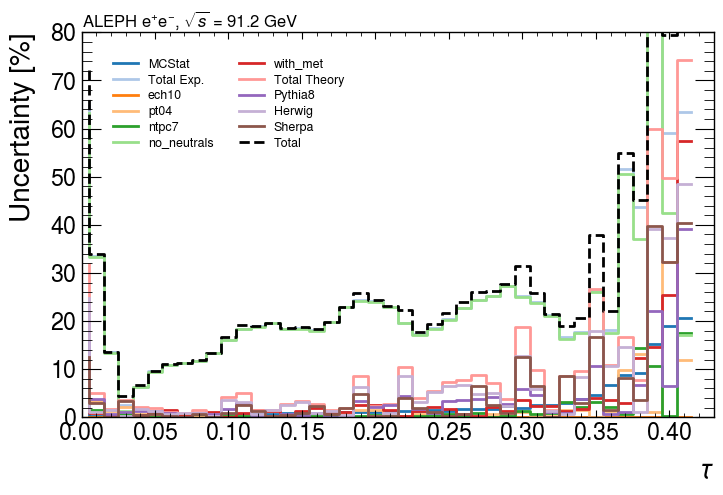

In [10]:
print("Reminder since divide by nominal we don't need to scale by hadronic event selection.")

# plot uncertainty breakdown
fig, ax = plt.subplots(figsize=(8, 5))
# Use a color cycle from matplotlib that doesn't repeat for the number of error components
colors = plt.cm.tab20.colors  # 20 unique colors
color_cycle = itertools.cycle(colors)

# bins and centers
bins = np.linspace(0, 0.42, 43)
x = (bins[:-1] + bins[1:]) / 2

# draw MC stat
ax.step(x, w["MCStat"]["nominal"]/w["Nominal"]["nominal"]*100, label="MCStat", color=next(color_cycle))

# draw experimental
ax.step(x, total_exp_syst/w["Nominal"]["nominal"]*100, label="Total Exp.", color=next(color_cycle))
for name, unc in zip(exp_syst_names, exp_syst):
    ax.step(x, np.abs(unc)/w["Nominal"]["nominal"]*100, label=name, color=next(color_cycle))
    
# draw theory
ax.step(x, total_th_syst/w["Nominal"]["nominal"]*100, label="Total Theory", color=next(color_cycle))
for name, unc in zip(th_syst_names, th_syst):
    ax.step(x, np.abs(unc)/w["Nominal"]["nominal"]*100, label=name, color=next(color_cycle))
    
# draw total
ax.step(x, total_uncert/w["Nominal"]["nominal"]*100, label="Total", color="Black", ls="--")

ax.text(0, 1, r"ALEPH e$^{+}$e$^{-}$, $\sqrt{s}$ = 91.2 GeV", transform=ax.transAxes, ha='left', va='bottom', fontsize=12)

ax.set_ylabel("Uncertainty [%]")
ax.set_ylim(0, 80)
ax.set_xlim(0, 0.43)
ax.set_xlabel(r"$\tau$")

ax.legend(ncol=2, fontsize=9, bbox_to_anchor=(0.02, 0.98), loc="upper left")

plt.show()

In [8]:
outFileName = os.path.join(top_dir, "ibu_results.npz")
print(outFileName)
np.savez(
    outFileName,
    # nominal result
    nominal = w["Nominal"]["nominal"],
    # MC uncertainty from bootstrapping
    mcstat = w["MCStat"]["nominal"],
    # experimental systematic
    exp_syst_names = exp_syst_names,
    exp_syst = exp_syst,
    total_exp_syst = total_exp_syst,
    # theory uncertainty from MC prior
    th_syst_names = th_syst_names,
    th_syst = th_syst,
    total_th_syst = total_th_syst,
    # total error from quadrature sum of mcstat, total exp syst, total theory syst
    total_uncert = total_uncert,
    # hadronic selection correction
    had_sel_corr = w["HadronicSelectionCorrection"]["nominal"],
)

/home/badea/e+e-/aleph/unfold-ee-logtau/ibu_results/training-be9fb5f7/ibu_results.npz


In [9]:
with np.load(outFileName) as data:
    for k in data.keys():
        v = data[k]
        # If it's an object array whose first element is a str, treat it as a text list
        if v.dtype == object and len(v) > 0 and isinstance(v[0], str):
            print(f"{k}: text list -> {v.tolist()}")
        else:
            print(f"{k}: numpy array, shape {v.shape}, dtype {v.dtype}")

nominal: numpy array, shape (42,), dtype float64
mcstat: numpy array, shape (42,), dtype float64
exp_syst_names: numpy array, shape (5,), dtype <U11
exp_syst: numpy array, shape (5, 42), dtype float64
total_exp_syst: numpy array, shape (42,), dtype float64
th_syst_names: numpy array, shape (3,), dtype <U7
th_syst: numpy array, shape (3, 42), dtype float64
total_th_syst: numpy array, shape (42,), dtype float64
total_uncert: numpy array, shape (42,), dtype float64
had_sel_corr: numpy array, shape (42,), dtype float64
